1.1 Visualizing the data


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("ex2data1.txt" ,header=None)
df.columns=["Test1_Score","Test2_Score","Admitted"]
df.head(5)

,Test1_Score,Test2_Score,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


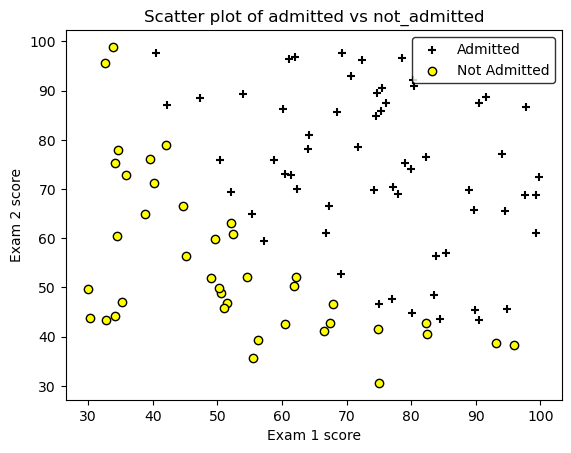

In [19]:
admitted=df[df["Admitted"]==1]
not_admitted=df[df["Admitted"]==0]

plt.scatter(admitted["Test1_Score"],admitted["Test2_Score"],marker='+',c="black",label="Admitted")
plt.scatter(not_admitted["Test1_Score"],not_admitted["Test2_Score"],marker='o',c="yellow",edgecolors="black",label="Not Admitted")
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("Scatter plot of admitted vs not_admitted")
plt.legend(loc="upper right",edgecolor="black")
plt.show()


1.2 Implementation

1.2.1 Warmup exercise: sigmoid function

In [21]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [26]:
print(sigmoid(100))
print(sigmoid(0))
print(sigmoid(-100))

1.0
0.5
3.7200759760208356e-44


1.2.2 Cost function and gradient

In [29]:
theta=np.zeros((3,1))
theta

array([[0.],
       [0.],
       [0.]])

In [30]:
#creating input and output
m=len(df)

X=np.c_[np.ones(m),df["Test1_Score"].values,df["Test2_Score"].values]
Y=df["Admitted"].values.reshape(m,1)

In [32]:
X.shape

(100, 3)

In [33]:
Y.shape

(100, 1)

In [55]:
def cost_and_gradient(theta,X,Y):
    Y=Y.flatten()
    m=len(Y)
    z= X @ theta
    h=sigmoid(z) #h(x)

    J=(-1/m)*np.sum(Y*np.log(h)+(1-Y)*np.log(1-h))

    grad = (1/m) * (X.T @ (h - Y))

    return J,grad


In [56]:
theta = np.zeros(X.shape[1])
J, grad = cost_and_gradient(theta, X, Y)

print("theta shape:", theta.shape)
print("grad shape:", grad.shape)
print("Cost:", J)


theta shape: (3,)
grad shape: (3,)
Cost: 0.6931471805599453


In [57]:
J,grad=cost_and_gradient(theta,X,Y)
print(J)
print(grad)

0.6931471805599453
[ -0.1        -12.00921659 -11.26284221]


1.2.3 Learning parameters using scipy.optimise

In [61]:
from scipy.optimize import minimize

def optimise_cost(X,Y):
    initial_theta=np.zeros(X.shape[1])

    res=minimize(
        fun=lambda t:cost_and_gradient(t,X,Y)[0],
        x0=initial_theta,
        jac=lambda t:cost_and_gradient(t,X,Y)[1],
        method='TNC',
        options={'maxfun': 400}
    )
    #res.x ->optimised theta and res.fun-->optimised cost
    return res.x ,res.fun

In [62]:
optimised_theta,optimised_cost=optimise_cost(X,Y)
print(optimised_theta)
print(optimised_cost)

[-25.16131847   0.20623159   0.20147148]
0.20349770158947525


1.2.4 Evaluating logistic regression

In [64]:
optimised_theta.reshape(X.shape[1],1)

array([[-25.16131847],
       [  0.20623159],
       [  0.20147148]])

In [68]:
def predict(theta,X):
    prob=sigmoid(X@theta)
    return (prob>=0.5).astype(int)

In [69]:
test1=[1,45,85]
print(predict(optimised_theta,test1))

1


In [78]:
#creating the equation
x1=np.linspace(30,100,100)
x2=(25.16-0.206*x1)/0.201

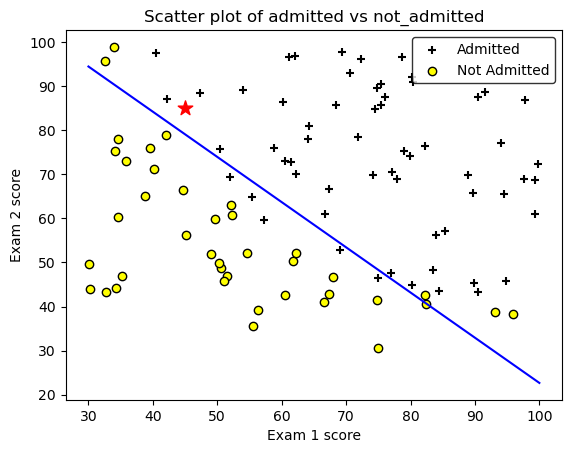

In [85]:
#plotting the decision boundary
plt.scatter(admitted["Test1_Score"],admitted["Test2_Score"],marker='+',c="black",label="Admitted")
plt.scatter(not_admitted["Test1_Score"],not_admitted["Test2_Score"],marker='o',c="yellow",edgecolors="black",label="Not Admitted")
plt.plot(x1,x2,"blue")
plt.scatter(45, 85, s=120, marker='*',c="red")
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("Scatter plot of admitted vs not_admitted")
plt.legend(loc="upper right",edgecolor="black")
plt.show()


2.1 Visualizing the data

In [86]:
df2=pd.read_csv("ex2data2.txt",header=None)
df2.columns=["Test1","Test2","QA"]
df2.head(5)

,Test1,Test2,QA
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [89]:
passed=df2[df2["QA"]==1]
failed=df2[df2["QA"]==0]


[]

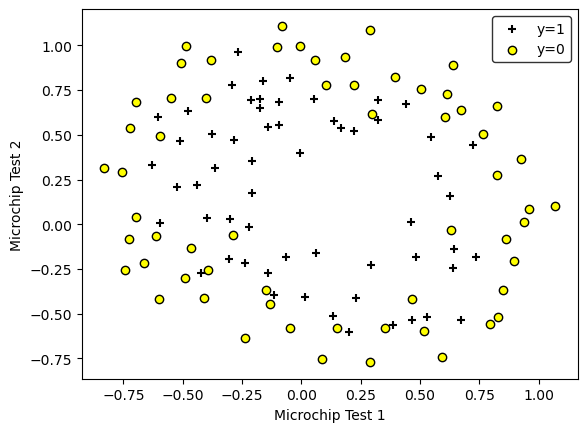

In [91]:
plt.scatter(passed["Test1"],passed["Test2"],marker="+",c="black",label="y=1")
plt.scatter(failed["Test1"],failed["Test2"],marker="o",c="yellow",edgecolors="black",label="y=0")
plt.xlabel("Microchip Test 1")
plt.ylabel("Microchip Test 2")
plt.legend(loc="upper right",edgecolor="black")
plt.plot()


2.2 Feature mapping

In [92]:
def feature_mapping(x1,x2,degree=6):
    x1=np.asarray(x1)
    x2=np.asarray(x2)

    out=[np.ones(x1.shape[0])]

    for i in range(1,degree+1):
        for j in range(i+1):
            out.append((x1**(i-j))*(x2**j))

    return np.stack(out,axis=1)

In [ ]:
fitting=feature_mapping(df2["Test1"],df2["Test2"])
print(fitting)

[[ 1.00000000e+00  5.12670000e-02  6.99560000e-01 ...  6.29470940e-04
   8.58939846e-03  1.17205992e-01]
 [ 1.00000000e+00 -9.27420000e-02  6.84940000e-01 ...  1.89305413e-03
  -1.39810280e-02  1.03255971e-01]
 [ 1.00000000e+00 -2.13710000e-01  6.92250000e-01 ...  1.04882142e-02
  -3.39734512e-02  1.10046893e-01]
 ...
 [ 1.00000000e+00 -4.84450000e-01  9.99270000e-01 ...  2.34007252e-01
  -4.82684337e-01  9.95627986e-01]
 [ 1.00000000e+00 -6.33640000e-03  9.99270000e-01 ...  4.00328554e-05
  -6.31330588e-03  9.95627986e-01]
 [ 1.00000000e+00  6.32650000e-01 -3.06120000e-02 ...  3.51474517e-07
  -1.70067777e-08  8.22905998e-10]]


(118, 28)